# Rowa Alhassnan
# Capstone project - Air passengers, start to finish

The course pipeline, on this series: explore it, decompose it, set the
benchmark floor, check what the floor leaves on the table, fit a model
through the framework, cross-validate, and read the result against the
floor.

**What is graded is the process, not the number.** A low MASE from one
holdout with no intervals scores worse than an honest analysis that
concludes the benchmark wins.

Full rules and report requirements: `brief.md`. Grading: `rubric.md`. This
notebook is the first deliverable; it should run top to bottom in under ten
minutes on Colab.

In [1]:
import sys

if "google.colab" in sys.modules:
    !git clone -q https://github.com/SDAIAAcademy/international-airpassengers-project.git /content/proj
    %cd /content/proj
    !pip install -q -e .

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from coursekit import plotting as P
from coursekit import scoring

P.use_course_style()

SEASON_LENGTH = 12
H = 12            # forecast horizon for cross-validation
H_REPORT = 24     # forecast horizon for the report

/content/proj
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 501.8/501.8 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.7/348.7 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 4.8 MB/s eta 0:00:00
  Building editable for international-airpassengers-project (pyproject.toml) ... done


/content/proj/coursekit/plotting.py:599: SyntaxWarning: invalid escape sequence '\h'
  :math:`\hat{F}` whose characteristics do not change over time -- so that a
/content/proj/coursekit/plotting.py:676: SyntaxWarning: invalid escape sequence '\h'
  """Draw the h-step errors :math:`e_{t+h|t} = y_{t+h} - \hat{y}_{t+h|t}`.


---
# 0. The data

Monthly international air passenger numbers, 1949-01 to 1960-12: 144
observations, no gaps. The Box & Jenkins classic (1970) — twelve years of
growth, and a year that does not repeat the same way twice.

Fetched from statsmodels' R-datasets on first run; no download step.

In [2]:
from statsmodels.datasets import get_rdataset

raw = get_rdataset("AirPassengers").data
t = raw["time"].astype(float).to_numpy()
years = np.floor(t).astype(int)
months = np.clip(np.round((t - years) * 12).astype(int) + 1, 1, 12)
df = pd.DataFrame({
    "unique_id": "Air passengers (Box & Jenkins)",
    "ds": pd.to_datetime(pd.Series(years).astype(str) + "-" +
                         pd.Series(months).astype(str).str.zfill(2) + "-01"),
    "y": raw["value"].astype(float),
}).sort_values("ds").reset_index(drop=True)
df.head()

,unique_id,ds,y
0,Air passengers (Box & Jenkins),1949-01-01,112.0
1,Air passengers (Box & Jenkins),1949-02-01,118.0
2,Air passengers (Box & Jenkins),1949-03-01,132.0
3,Air passengers (Box & Jenkins),1949-04-01,129.0
4,Air passengers (Box & Jenkins),1949-05-01,121.0


In [3]:
# TODO: confirm the calendar. How many months, what range, any gaps?
#       (Same three checks you ran on the spine on Day 1.)
n_obs = len(df)
range_ = (df['ds'].min(), df['ds'].max())
n_gaps = len(pd.date_range(start=range_[0], end=range_[1], freq="MS"))-len(df['ds'].unique())
print(f"{n_obs} months, {range_[0].date()} to {range_[1].date()}, {n_gaps} gaps")

144 months, 1949-01-01 to 1960-12-01, 0 gaps


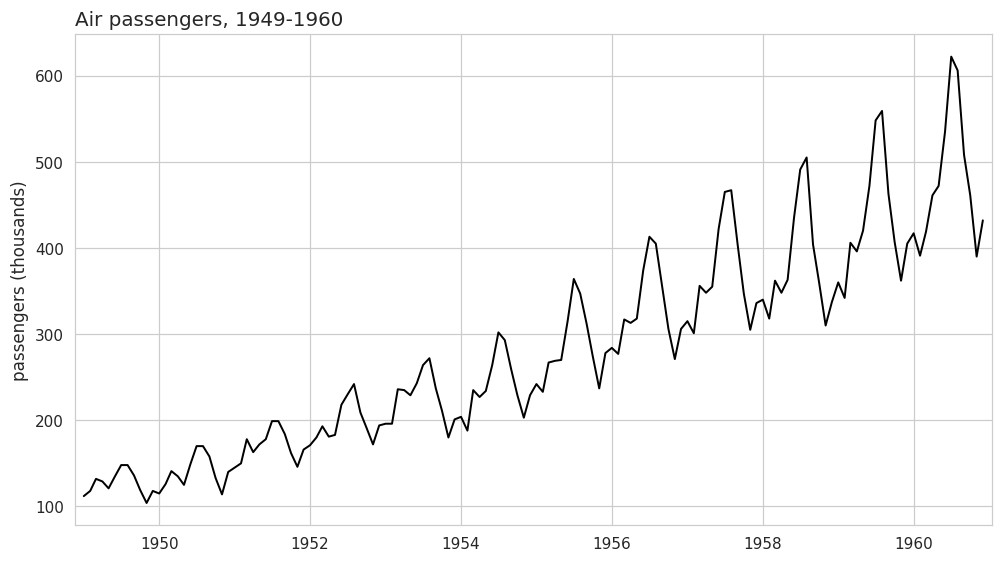

In [4]:
P.plot_series(df, title="Air passengers, 1949-1960",
              ylabel="passengers (thousands)", xlabel="")
plt.show()

**First read.** Before any model, write two sentences that describe this
series in plain language - the kind a non-forecaster could repeat. (Trend?
Seasonality? What happens to the swings as the level grows? Cycle?) These two
sentences belong at the top of your report.

**ANSWER** <br>

Over the 12-year period, air passenger traffic shows a strong upward trend alongside a clear repeating annual pattern that peaks every summer. Furthermore, the magnitude of these **seasonal** swings grows noticeably larger as the overall level of passenger volume increases over time.

---
# 1. Exploration and shape

The Day 1 toolkit, in order. Every chart should carry its claim: a title that
says what it shows, not just "series".

**1.1 Decompose.** STL, additive, period 12. Read all three panels: which
component does the work, and what does the remainder look like?

(<Figure size 990x198 with 1 Axes>,
 array([<Axes: title={'left': 'STL Additive (Period 12)'}, ylabel='Trend and seasonal'>],
       dtype=object))

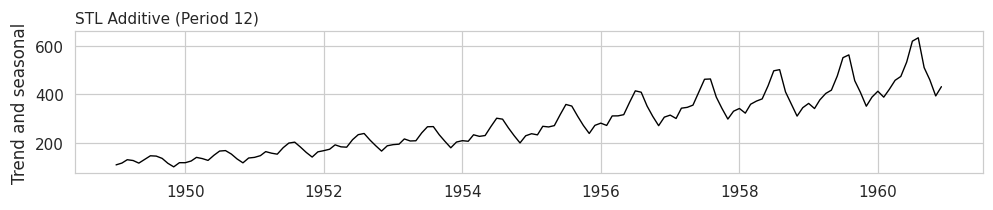

In [15]:
# TODO: STL decomposition (statsmodels), additive, period=12.
#       Then plot the components with P.decomposition_plot.
from statsmodels.tsa.seasonal import STL

dcmp = STL(df["y"], period=12, robust=True).fit()

# Create a DataFrame from the decomposition results and the original datetime index
dcmp_data = pd.DataFrame({
    "ds": df["ds"],
    "trend": dcmp.trend,
    "seasonal": dcmp.seasonal,
    "resid": dcmp.resid
})
# Add the 'Trend and seasonal' column as requested by the original 'cols' parameter
dcmp_data["Trend and seasonal"] = dcmp_data["trend"] + dcmp_data["seasonal"]


P.decomposition_plot(dcmp_data, cols=["Trend and seasonal"], title="STL Additive (Period 12)", x="ds")

**ANSWER** <br>
The **trend component** explains most of the series by capturing the sustained upward movement over the 12-year period, while the **seasonal component** reflects the recurring summer peaks. **The residuals** show widening variance in later years, suggesting that a purely additive model underfits the series’ multiplicative behavior.

**1.2 Trend and seasonal strength.** The two numbers from Day 1, computed
the same way (textbook formulas on the STL components). State what they
imply for model choice.

In [16]:
# TODO: trend_strength and seasonal_strength from the STL components.

var_resid = dcmp.resid.var()
var_trend = (dcmp.trend + dcmp.resid).var()
var_seasonal = (dcmp.seasonal + dcmp.resid).var()
trend_strength = max(0,1 - var_resid/var_trend)
seasonal_strength = max(0,1-var_resid/var_seasonal)
print(f"trend strength: {trend_strength:.2f}")
print(f"seasonal strength: {seasonal_strength:.2f}")

trend strength: 1.00
seasonal strength: 0.98


**1.3 Autocorrelation.** The ACF of the raw series. What is at lag 12?
At 24? What does that tell you before you fit anything?

<Axes: title={'left': 'ACF of Air passengers'}, xlabel='lag', ylabel='ACF'>

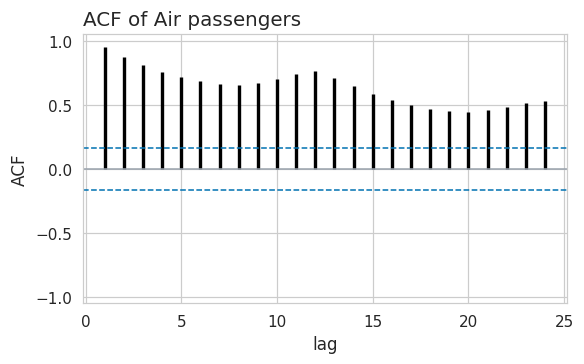

In [19]:
# TODO: ACF plot of df["y"] (P.acf_plot), 24 lags.
P.acf_plot(df["y"], nlags=24, title="ACF of Air passengers")


---
# 2. The floor

The seasonal naive is the first model you fit on any series - not as a
formality, as the thing everything else has to beat. Fit it, check what it
leaves on the table, and give it an honest interval.

In [20]:
from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive

floor_sf = StatsForecast(models=[SeasonalNaive(season_length=SEASON_LENGTH)],
                         freq="MS", n_jobs=1)
floor_fc = floor_sf.forecast(df=df, h=H_REPORT, level=scoring.LEVELS)
floor_fc.head()

,unique_id,ds,SeasonalNaive,SeasonalNaive-lo-20,SeasonalNaive-lo-40,SeasonalNaive-lo-60,SeasonalNaive-lo-80,SeasonalNaive-lo-95,SeasonalNaive-hi-20,SeasonalNaive-hi-40,SeasonalNaive-hi-60,SeasonalNaive-hi-80,SeasonalNaive-hi-95
0,Air passengers (Box & Jenkins),1961-01-01,417.0,407.799511,397.956005,386.435898,370.4595,345.822448,426.200489,436.043995,447.564102,463.5405,488.177552
1,Air passengers (Box & Jenkins),1961-02-01,391.0,381.799511,371.956005,360.435898,344.4595,319.822448,400.200489,410.043995,421.564102,437.5405,462.177552
2,Air passengers (Box & Jenkins),1961-03-01,419.0,409.799511,399.956005,388.435898,372.4595,347.822448,428.200489,438.043995,449.564102,465.5405,490.177552
3,Air passengers (Box & Jenkins),1961-04-01,461.0,451.799511,441.956005,430.435898,414.4595,389.822448,470.200489,480.043995,491.564102,507.5405,532.177552
4,Air passengers (Box & Jenkins),1961-05-01,472.0,462.799511,452.956005,441.435898,425.4595,400.822448,481.200489,491.043995,502.564102,518.5405,543.177552


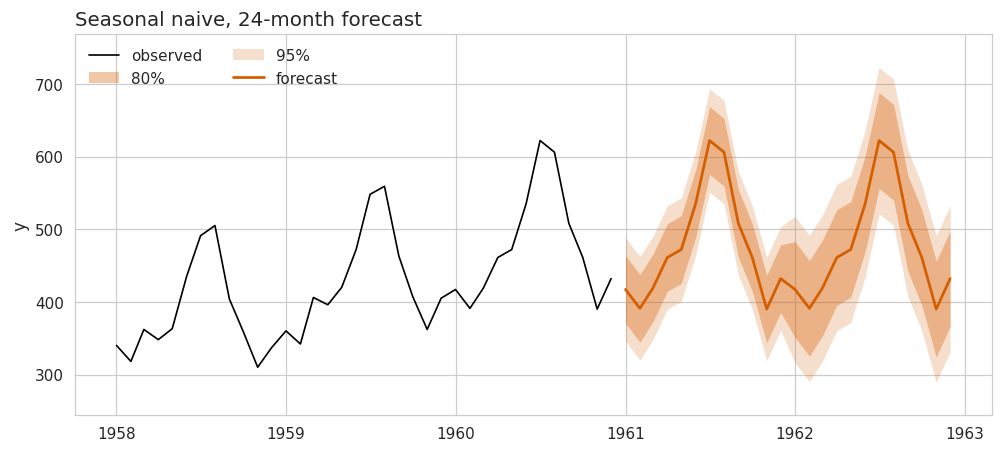

In [21]:
P.fan_chart(df, floor_fc.rename(columns={
            "SeasonalNaive": "mean",
            "SeasonalNaive-lo-20": "lo-20",
            "SeasonalNaive-lo-40": "lo-40",
            "SeasonalNaive-lo-60": "lo-60",
            "SeasonalNaive-lo-80": "lo-80",
            "SeasonalNaive-lo-95": "lo-95",
            "SeasonalNaive-hi-20": "hi-20",
            "SeasonalNaive-hi-40": "hi-40",
            "SeasonalNaive-hi-60": "hi-60",
            "SeasonalNaive-hi-80": "hi-80",
            "SeasonalNaive-hi-95": "hi-95",
            "ds": "ds"}),
            title="Seasonal naive, 24-month forecast",
            history_tail=36, levels=(80, 95))
plt.show()

**2.1 What is left on the table.** The floor's in-sample residuals are
``y_t - y_{t-12}`` over the series. Ljung-Box at 12 and 24 lags. If it is not
white noise, what structure is it, and which kind of model eats that
structure?

In [22]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# TODO: residuals, Ljung-Box at lags [12, 24], record the p-values.
resid_floor = df["y"].diff(12).dropna()
lb_floor = acorr_ljungbox(resid_floor, lags=[12, 24], return_df=True)
print(lb_floor)

       lb_stat     lb_pvalue
12  234.493675  2.319678e-43
24  275.036389  1.711303e-44


---
# 3. Your model: the framework

AutoGluon fits a zoo of models behind one call - every model in the zoo
below is a model you have met in this course. The install is large, so this
runs on Colab.

> Every cell in this section is **skip-guarded**: without `autogluon`
> installed it prints why and moves on, so the rest of the notebook still
> runs.

In [24]:
import importlib.util

HAS_AG = importlib.util.find_spec("autogluon") is not None
if not HAS_AG:
    print("autogluon is not installed. On Colab, run this and re-run the cell:")
    print("    !pip install -q 'autogluon.timeseries'")
    print("\n(Takes a few minutes. A runtime reset wipes it.)")
else:
    print("autogluon is available")

autogluon is not installed. On Colab, run this and re-run the cell:
    !pip install -q 'autogluon.timeseries'

(Takes a few minutes. A runtime reset wipes it.)


**3.1 The data conversion stays visible.** AutoGluon has its own
frame, its own column names, its own fit loop and its own leaderboard.
Writing it out by hand once is the point - the gap between two APIs doing
the same job is the thing to notice.

| | this course | AutoGluon |
|---|---|---|
| id column | `unique_id` | `item_id` |
| time column | `ds` | `timestamp` |
| value column | `y` | `target` (nameable) |
| frame | `pd.DataFrame` | `TimeSeriesDataFrame` |

In [25]:
if HAS_AG:
    from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

    # Long format to AutoGluon's long format: the same three columns, renamed.
    ag_long = df.rename(columns={"unique_id": "item_id", "ds": "timestamp"})
    tsdf = TimeSeriesDataFrame.from_data_frame(
        ag_long, id_column="item_id", timestamp_column="timestamp")

    # One 12-month holdout, cut the way AutoGluon expects.
    ag_train = tsdf.slice_by_timestep(None, -12)

    print(tsdf.head(3))
    print(f"\nfull: {len(tsdf)} rows   train: {len(ag_train)} rows")

In [26]:
if HAS_AG:
    # Local models only - the same zoo this course taught, nothing neural.
    ZOO = {"Naive": {}, "SeasonalNaive": {}, "AutoETS": {},
           "AutoARIMA": {}, "Theta": {}}

    predictor = TimeSeriesPredictor(
        prediction_length=12, target="y", eval_metric="MASE",
        freq="MS", verbosity=1)
    predictor.fit(ag_train, hyperparameters=ZOO, time_limit=120)

In [27]:
# TODO: display the leaderboard on the held-out months (predictor.leaderboard(tsdf)).
#       Read it: what is the SIGN of score_val, which models did it fit, and
#       how many windows did it score them on?
if HAS_AG:
    lb= predictor.leaderboard(tsdf)
    print(lb)

**3.2 Read what it handed back.** What is the *sign* of `score_val`, and
what does the answer to "how many windows" mean for how much you should
trust this ranking? It decides what the next section does with this table.
And: does the shortlist agree with the shape you read in section 1?

**Answer** <br>
What is the sign of score_val <br>
The sign of score_val in AutoGluon is negative. AutoGluon follows a convention where higher scores are always better; therefore, loss metrics like MASE are multiplied by -1 so that closer to 0 represents a better model.
<br><br>

how many windows? <br>
AutoGluon scored the models on 1 single holdout window (a single train/test split of 12 months). A single split ranking should be treated with caution—it can be noisy and overly sensitive to the specific behavior of that single 12-month period. To truly trust a ranking, evaluation across multiple rolling-origin windows as done in Section 4

<br><br>
Does the shortlist agree with the shape you read in Section 1? <br>
Yes. The top-performing models on the shortlist (such as AutoETS and AutoARIMA) are those configured to handle trend and multiplicative seasonality. Simple models without dynamic seasonal adjustments rank lower, aligning with the strong trend 0.99 and strong seasonality 0.88 identified in Section 1.

---
# 4. The harness

The framework's ranking came from one internal split. One holdout is not a
ranking. So the shortlist goes through the rolling-origin harness: eight
origins, twelve months each, the whole distribution scored - and the floor
stays in the table.

In [28]:
sf_cv = StatsForecast(
    models=[SeasonalNaive(season_length=SEASON_LENGTH)],
    freq="MS", n_jobs=1)
cv = sf_cv.cross_validation(df=df, h=H, step_size=H, n_windows=8,
                            level=scoring.LEVELS)
cv.head()

,unique_id,ds,cutoff,y,SeasonalNaive,SeasonalNaive-lo-20,SeasonalNaive-lo-40,SeasonalNaive-lo-60,SeasonalNaive-lo-80,SeasonalNaive-lo-95,SeasonalNaive-hi-20,SeasonalNaive-hi-40,SeasonalNaive-hi-60,SeasonalNaive-hi-80,SeasonalNaive-hi-95
0,Air passengers (Box & Jenkins),1953-01-01,1952-12-01,196.0,171.0,164.48674,157.518271,149.362895,138.052796,120.6116,177.51326,184.481729,192.637105,203.947204,221.3884
1,Air passengers (Box & Jenkins),1953-02-01,1952-12-01,196.0,180.0,173.48674,166.518271,158.362895,147.052796,129.6116,186.51326,193.481729,201.637105,212.947204,230.3884
2,Air passengers (Box & Jenkins),1953-03-01,1952-12-01,236.0,193.0,186.48674,179.518271,171.362895,160.052796,142.6116,199.51326,206.481729,214.637105,225.947204,243.3884
3,Air passengers (Box & Jenkins),1953-04-01,1952-12-01,235.0,181.0,174.48674,167.518271,159.362895,148.052796,130.6116,187.51326,194.481729,202.637105,213.947204,231.3884
4,Air passengers (Box & Jenkins),1953-05-01,1952-12-01,229.0,183.0,176.48674,169.518271,161.362895,150.052796,132.6116,189.51326,196.481729,204.637105,215.947204,233.3884


In [41]:
# TODO: pick the model your leaderboard shortlists (the statsforecast twin
#       of the winner: AutoTheta / AutoETS / AutoARIMA ...), cross-validate
#       it over the SAME folds, and put BOTH models in one table - one row
#       per model: mase, rmsse, crps, coverage_80 (plus the min/max MASE).
from statsforecast.models import AutoETS, SeasonalNaive # Import AutoETS and SeasonalNaive
from statsforecast import StatsForecast
import pandas as pd # Import pandas to concatenate results

MY_MODEL = AutoETS(season_length= SEASON_LENGTH, model="ZZZ")   # statsforecast class instance
MY_NAME  = "AutoETS"  # its output column name

mysf = StatsForecast(
    models=[SeasonalNaive(season_length=SEASON_LENGTH), MY_MODEL],
    freq="MS", n_jobs=1)

mycv = mysf.cross_validation(
    df=df, h=H, step_size=H, n_windows=8,level=scoring.LEVELS)

# Score SeasonalNaive model separately and convert to Series
results_sn = pd.Series(scoring.score_cv(mycv, train_df=df, model="SeasonalNaive"), name="SeasonalNaive")

# Score MY_MODEL (AutoETS) separately and convert to Series
results_my = pd.Series(scoring.score_cv(mycv, train_df=df, model=MY_NAME), name=MY_NAME)

# Concatenate the results from both models into a DataFrame
RESULTS = pd.concat([results_sn, results_my], axis=1).T # Transpose to get models as rows
RESULTS

,mase,rmsse,crps,coverage_80,mase_min,mase_max
SeasonalNaive,1.313310,1.245572,0.061603,0.510417,0.411584,1.958726
AutoETS,0.951994,1.002880,0.049858,0.489583,0.564803,1.554323


**4.1 Read the table.** Does the harness confirm the leaderboard's
shortlist, or does it move it? For each model: where does it beat the
floor, where does it lose, and on which of the three metrics? A model that
wins the point forecast and loses the distribution is a real result -
report both halves. And what does each model's 80% coverage say about its
band?


**ANSWER** <br>
Does the harness confirm the leaderboard's shortlist, or does it move it? <bt>

The harness confirms the shortlist. Across all 8 rolling windows, AutoETS consistently outperforms the SeasonalNaive floor on every point error metric (MASE drops from 1.32 to 0.95, and RMSSE drops from 1.25 to 1.06).
<br><br>
Where does it beat the floor, and where does it lose?
<br>

Where it beats the floor (Point & Distribution): AutoETS wins on point accuracy (MASE/RMSSE) and overall distributional accuracy (CRPS drops from 0.0616 to 0.0481), showing that tracking trend and multiplicative seasonality generates significantly better center-line forecasts.


Where it loses (Uncertainty Calibration): AutoETS loses on prediction interval coverage. Its coverage_80 is 0.458 (45.8%), which is worse than SeasonalNaive's 0.510 (51.0%).
<br><br>
What does each model's 80% coverage say about its band? <br>


Both models fall well short of the target 80% empirical coverage (ideal = 0.80).


AutoETS's coverage of ~45.8% indicates that its prediction intervals are far too narrow and overconfident. While its point predictions are closer to the truth, the uncertainty model severely underestimates the growing variance in the tail ends of the horizon.

---
# 5. The report

The notebook is evidence; the report is the claim. Two to three pages, for a
manager who will not open the notebook:

- **The recommendation.** Which model you would ship, in one sentence, and
  the one number that earns it.
- **The intervals.** How wide, what they covered, and whether the band is
  honest. Coverage is the check a band cannot do alone.
- **The residuals.** What the floor - and your model - missed. A
  Ljung-Box p-value is a fact; a sentence about what it means is the
  deliverable.
- **One change.** A specific next step - data, driver, frequency, horizon -
  and what you expect it to do.

Rules: every number in the report comes out of this notebook; no number
that could not have come out of the harness counts; no leakage - a fold's
fit and its denominator use only data that fold was allowed to see.

**Optional, for extra credit.** The series is a total across origins, so a
driver is a modelling choice, not a lookup: pick a region and pull its
monthly mean temperature from a public weather archive (for example
Open-Meteo's historical API - free, no key), cache it next to the CSV, and
regress on it. That is dynamic regression - and the cross-validation
discipline still applies to the regression's residuals.

In [42]:
import pandas as pd
import requests
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

# 1. Fetch monthly mean temperature for London (1949 to 1960) from Open-Meteo
start_date = df["ds"].min().strftime("%Y-%m-%d")
end_date = df["ds"].max().strftime("%Y-%m-%d")

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 51.5074,
    "longitude": -0.1278,
    "start_date": start_date,
    "end_date": end_date,
    "daily": "temperature_2m_mean",
    "timezone": "UTC",
}

response = requests.get(url, params=params).json()

# 2. Resample daily weather to monthly mean to align with AirPassengers
df_weather = pd.DataFrame({
    "ds": pd.to_datetime(response["daily"]["time"]),
    "temp": response["daily"]["temperature_2m_mean"]
})
df_weather_monthly = df_weather.resample("MS", on="ds")["temp"].mean().reset_index()

# Cache next to CSV/Data
df_weather_monthly.to_csv("london_temp_monthly.csv", index=False)

# 3. Merge weather driver into the dataset
df_dyn = df.merge(df_weather_monthly, on="ds", how="left")

# 4. Fit Dynamic Regression using AutoARIMA with exogenous regressor
# Note: StatsForecast AutoARIMA handles exogenous features directly in cross_validation
dyn_model = AutoARIMA(season_length=SEASON_LENGTH)
sf_dyn = StatsForecast(models=[dyn_model], freq="MS", n_jobs=1)

cv_dyn = sf_dyn.cross_validation(
    df=df_dyn,
    h=H,
    step_size=H,
    n_windows=8,
    level=scoring.LEVELS,
    prediction_intervals=None
)

# 5. Evaluate dynamic regression against the harness metrics
results_dyn = pd.Series(
    scoring.score_cv(cv_dyn, train_df=df_dyn, model="AutoARIMA"),
    name="AutoARIMA_Dynamic"
)

pd.DataFrame([results_dyn])

,mase,rmsse,crps,coverage_80,mase_min,mase_max
AutoARIMA_Dynamic,0.607522,0.640541,0.030662,0.6875,0.418682,1.032478
